# 03 - Bounded Public REST Extraction

Checkpoint 2: inspect the latest bounded Fink LSST public REST extraction. This notebook reads saved artifacts only; it does not make live API calls and does not claim full-night completeness.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

latest_path = ROOT / "outputs" / "bounded_extraction" / "latest_run.json"
latest = json.loads(latest_path.read_text())
raw_dir = Path(latest["raw_dir"])
processed_dir = Path(latest["processed_dir"])
output_dir = Path(latest["output_dir"])
latest

{'feasibility_report': '/Users/darim_shamsi/Documents/Fink Analysis/outputs/bounded_extraction/20260623T192730Z/FEASIBILITY_REPORT.md',
 'manifest': '/Users/darim_shamsi/Documents/Fink Analysis/outputs/bounded_extraction/20260623T192730Z/manifest.json',
 'output_dir': '/Users/darim_shamsi/Documents/Fink Analysis/outputs/bounded_extraction/20260623T192730Z',
 'processed_dir': '/Users/darim_shamsi/Documents/Fink Analysis/data/processed/bounded_extraction/20260623T192730Z',
 'raw_dir': '/Users/darim_shamsi/Documents/Fink Analysis/data/raw/bounded_extraction/20260623T192730Z',
 'run_id': '20260623T192730Z'}

## Artifact Map

In [2]:
pd.DataFrame(
    [
        {"artifact": "raw_dir", "path": raw_dir, "exists": raw_dir.exists()},
        {"artifact": "processed_dir", "path": processed_dir, "exists": processed_dir.exists()},
        {"artifact": "output_dir", "path": output_dir, "exists": output_dir.exists()},
        {"artifact": "manifest", "path": Path(latest["manifest"]), "exists": Path(latest["manifest"]).exists()},
        {"artifact": "feasibility_report", "path": Path(latest["feasibility_report"]), "exists": Path(latest["feasibility_report"]).exists()},
    ]
)

,artifact,path,exists
0,raw_dir,/Users/darim_shamsi/Documents/Fink Analysis/da...,True
1,processed_dir,/Users/darim_shamsi/Documents/Fink Analysis/da...,True
2,output_dir,/Users/darim_shamsi/Documents/Fink Analysis/ou...,True
3,manifest,/Users/darim_shamsi/Documents/Fink Analysis/ou...,True
4,feasibility_report,/Users/darim_shamsi/Documents/Fink Analysis/ou...,True


## Extraction Summary

In [3]:
summary = json.loads((processed_dir / "extraction_summary.json").read_text())
manifest = json.loads((processed_dir / "manifest.json").read_text())

summary_rows = [
    {"metric": "run_id", "value": latest["run_id"]},
    {"metric": "tag_rows", "value": summary.get("tag_rows")},
    {"metric": "unique_object_ids", "value": summary.get("unique_object_ids")},
    {"metric": "detail_object_count", "value": summary.get("detail_object_count")},
    {"metric": "unique_source_ids", "value": summary.get("unique_source_ids")},
    {"metric": "statistics_payload_available", "value": summary.get("statistics_payload_available")},
]
pd.DataFrame(summary_rows)

,metric,value
0,run_id,20260623T192730Z
1,tag_rows,50
2,unique_object_ids,15
3,detail_object_count,10
4,unique_source_ids,50
5,statistics_payload_available,True


In [4]:
pd.DataFrame(
    [{"table": name, **shape} for name, shape in summary.get("table_shapes", {}).items()]
).sort_values("table").reset_index(drop=True)

,table,columns,rows
0,forced_photometry,20,5613
1,object_summary,10,15
2,objects,13,10
3,sources,21,4909
4,statistics,24,81
5,tag_rows,21,50


## Endpoint Capabilities

In [5]:
capabilities = pd.read_json(output_dir / "endpoint_capabilities.json")
capability_cols = [
    "path",
    "methods",
    "supports_row_limit",
    "supports_pagination_or_continuation",
    "supports_date_or_night_filter",
    "supports_tag_or_class_filter",
    "requires_diaObjectId",
    "safe_for_bounded_public_rest",
]
capabilities[capability_cols]

,path,methods,supports_row_limit,supports_pagination_or_continuation,supports_date_or_night_filter,supports_tag_or_class_filter,requires_diaObjectId,safe_for_bounded_public_rest
0,/api/v1/tags,"[GET, POST]",True,False,True,True,False,True
1,/api/v1/statistics,"[GET, POST]",False,False,True,False,False,True
2,/api/v1/objects,"[GET, POST]",False,False,False,False,True,True
3,/api/v1/sources,"[GET, POST]",False,False,False,False,True,True
4,/api/v1/fp,"[GET, POST]",False,False,False,False,True,True
5,/api/v1/conesearch,"[GET, POST]",True,False,True,False,False,True
6,/api/v1/blocks,[GET],False,False,False,False,False,True


## Normalized Tables

In [6]:
tables = {
    path.stem: pd.read_parquet(path)
    for path in processed_dir.glob("*.parquet")
}
pd.DataFrame(
    [
        {
            "table": name,
            "rows": len(df),
            "columns": len(df.columns),
            "columns_preview": ", ".join(list(df.columns)[:8]),
        }
        for name, df in sorted(tables.items())
    ]
)

,table,rows,columns,columns_preview
0,forced_photometry,5613,20,"r:band, r:dec, r:diaForcedSourceId, r:diaObjec..."
1,object_summary,15,10,"internal_table_type, internal_object_id, row_c..."
2,objects,10,13,"f:firstDiaSourceMjdTaiFink, f:main_label_class..."
3,sources,4909,21,"f:clf_cats_class, f:clf_cats_score, r:band, r:..."
4,statistics,81,24,"f:alerts, f:alerts_g, f:alerts_i, f:alerts_r, ..."
5,tag_rows,50,21,"f:clf_cats_class, f:clf_cats_score, r:band, r:..."


In [7]:
tables["object_summary"].sort_values("source_count", ascending=False).head(10)

,internal_table_type,internal_object_id,row_count,source_count,first_time_mjd,last_time_mjd,bands,ra,dec,_unmapped_fields
13,object_summary,313928193955332182,7,7,61041.220126,61041.231954,i,54.073416,-26.738353,[]
0,object_summary,313699514821640259,6,6,61041.220597,61041.232418,i,51.620555,-28.114117,[]
2,object_summary,313853500979675176,6,6,61041.220126,61041.232418,i,52.467345,-27.057596,[]
11,object_summary,313888627082919999,4,4,61041.223448,61041.228419,i,150.170666,1.368229,[]
4,object_summary,313853517400375398,3,3,61041.223448,61041.228419,i,149.533117,3.296081,[]
5,object_summary,313853517428162578,3,3,61041.223448,61041.228419,i,150.549329,2.626888,[]
6,object_summary,313853517466435621,3,3,61041.223448,61041.228419,i,149.261437,1.291211,[]
7,object_summary,313853517556613125,3,3,61041.223448,61041.227924,i,150.814482,3.357805,[]
8,object_summary,313853517578633281,3,3,61041.223448,61041.228419,i,149.936802,2.149247,[]
9,object_summary,313853517668810773,3,3,61041.223448,61041.228419,i,149.748554,3.701666,[]


In [8]:
preview_columns = [
    column
    for column in ["internal_object_id", "internal_source_id", "ra", "dec", "time_mjd", "band", "flux", "flux_err", "class_label"]
    if column in tables["tag_rows"].columns
]
tables["tag_rows"][preview_columns].head(10)

,internal_object_id,internal_source_id,ra,dec,time_mjd,band,flux,flux_err,class_label
0,313853500979675176,313928195952345097,52.467345,-27.057596,61041.232418,i,3623.3972,374.78790,11
1,313699514821640259,313928195905159220,51.620555,-28.114117,61041.232418,i,31503.6900,442.85358,11
2,313928193955332182,313928195836477544,54.073416,-26.738353,61041.231954,i,80609.0500,688.39160,11
3,313853500979675176,313928195821273100,52.467359,-27.057541,61041.231954,i,2722.2402,369.08322,11
4,313853500979675176,313928195664511042,52.467396,-27.057551,61041.231490,i,3122.5527,374.74660,11
5,313699514821640259,313928195637772309,51.620552,-28.114127,61041.231490,i,30237.3400,447.27084,11
6,313928193955332182,313928195700686927,54.073467,-26.738353,61041.231490,i,75383.1600,623.53940,11
7,313699514821640259,313928195499884596,51.620556,-28.114118,61041.231027,i,31515.2420,481.43650,11
8,313853500979675176,313928195550740483,52.467385,-27.057562,61041.231027,i,3297.3882,407.00546,11
9,313928193955332182,313928195564371988,54.073458,-26.738362,61041.231027,i,76074.6100,659.91364,11


## Quick Diagnostics

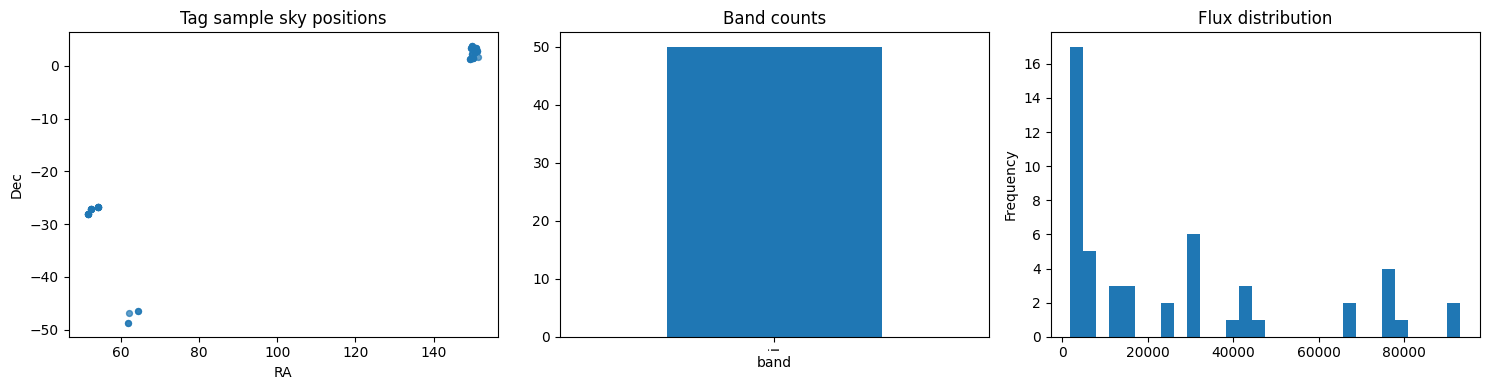

In [9]:
tag_rows = tables["tag_rows"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if {"ra", "dec"}.issubset(tag_rows.columns):
    axes[0].scatter(tag_rows["ra"], tag_rows["dec"], s=18, alpha=0.7)
    axes[0].set_xlabel("RA")
    axes[0].set_ylabel("Dec")
    axes[0].set_title("Tag sample sky positions")
else:
    axes[0].axis("off")

if "band" in tag_rows.columns:
    tag_rows["band"].value_counts(dropna=False).sort_index().plot(kind="bar", ax=axes[1])
    axes[1].set_title("Band counts")
else:
    axes[1].axis("off")

if "flux" in tag_rows.columns:
    tag_rows["flux"].dropna().plot(kind="hist", bins=30, ax=axes[2])
    axes[2].set_title("Flux distribution")
else:
    axes[2].axis("off")

plt.tight_layout()

## Validation And Feasibility

In [10]:
validation = json.loads((output_dir / "validation_report.json").read_text())
checks = pd.DataFrame(validation["checks"])
checks.groupby(["severity", "passed"]).size().rename("count").reset_index()

,severity,passed,count
0,error,True,31
1,info,True,32
2,warning,False,1


In [11]:
checks.loc[~checks["passed"], [column for column in ["severity", "table", "check", "message"] if column in checks.columns]]

,severity,table,check,message
63,warning,NaN,truncation_pagination,Response hit requested limit; additional rows ...


In [12]:
feasibility = json.loads((output_dir / "feasibility_report.json").read_text())
pd.DataFrame(
    [
        {"question": "Minimal lookup", "answer": feasibility["public_rest_minimal_lookup"]},
        {"question": "Bounded tag/window extraction", "answer": feasibility["public_rest_bounded_tag_window_extraction"]},
        {"question": "Complete full-night all-alert extraction", "answer": feasibility["public_rest_complete_full_night_all_alert_extraction"]},
    ]
)

,question,answer
0,Minimal lookup,yes
1,Bounded tag/window extraction,yes
2,Complete full-night all-alert extraction,unresolved


In [13]:
print("Blockers:")
for blocker in feasibility.get("blockers", []):
    print(f"- {blocker}")

print("\nRequired next tests:")
for item in feasibility.get("required_next_tests", []):
    print(f"- {item}")

Blockers:
- No all-pages pagination/continuation strategy has been proven.
- Bounded tag/window rows are not equivalent to complete nightly all-alert extraction.
- The bounded tag response hit the configured row limit, so additional matching rows may exist.

Required next tests:
- Test explicit pagination/limit behavior if exposed by future contracts.
- Run multiple small date/tag windows and compare against matching statistics if available.
- Determine whether public REST can enumerate all alerts for one night without Data Transfer.


## Checkpoint 2 Interpretation

- Public REST can support bounded tag/date-window samples with explicit row caps.
- Public REST can support known-ID object, source, and forced-photometry detail retrieval for a capped object list.
- The current run hit the configured tag row limit, so additional matching rows may exist.
- Statistics are useful context but are not a matching completeness denominator for this tag/date-window sample.
- Complete full-night all-alert extraction remains unresolved and may require Data Transfer in a later phase.